In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import cv2

In [4]:
# Function to load and preprocess images
def load_and_preprocess_data(folder_path, label):
    data = []
    labels = []
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (64, 64))  # Adjust the size as needed
        data.append(img)
        labels.append(label)
    return data, labels

In [5]:
# Load and preprocess data
dataset_folder="/content/drive/MyDrive/Machine Learning/Notebooks/Dataset/"
mild_demented_data, mild_demented_labels = load_and_preprocess_data(os.path.join(dataset_folder,'Mild_Demented'), 0)
moderate_demented_data, moderate_demented_labels = load_and_preprocess_data(os.path.join(dataset_folder,'Moderate_Demented'), 1)
non_demented_data, non_demented_labels = load_and_preprocess_data(os.path.join(dataset_folder,'Non_Demented'), 2)
very_mild_demented_data, very_mild_demented_labels = load_and_preprocess_data(os.path.join(dataset_folder,'Very_Mild_Demented'), 3)

In [6]:
# Combine data and labels
data = np.array(mild_demented_data + moderate_demented_data + non_demented_data + very_mild_demented_data)
labels = np.array(mild_demented_labels + moderate_demented_labels + non_demented_labels + very_mild_demented_labels)

In [7]:
# Convert labels to one-hot encoding
labels_one_hot = to_categorical(labels, num_classes=4)

In [8]:
# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')  # Adjust the number of units for the output layer
])

In [9]:
# Train the CNN model
epochs=10
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
# Split the data into training, validation, and test sets
train_data, test_data, train_labels, test_labels = train_test_split(data, labels_one_hot, test_size=0.2, random_state=42)
train_data, val_data, train_labels, val_labels = train_test_split(train_data, train_labels, test_size=0.2, random_state=42)

In [11]:
# Normalize pixel values to be between 0 and 1
train_data = train_data / 255.0
val_data = val_data / 255.0
test_data = test_data / 255.0

In [12]:
# Lists to store accuracy values
train_accuracy_list = []
val_accuracy_list = []
test_accuracy_list = []

# Lists to store loss values
train_loss_list = []
val_loss_list = []
test_loss_list = []

# Train the model
for epoch in range(epochs):
    history = model.fit(
        np.expand_dims(train_data, axis=-1), train_labels,
        epochs=1, batch_size=32, validation_data=(np.expand_dims(val_data, axis=-1), val_labels)
    )

    # Evaluate on training, validation, and test sets
    train_loss, train_accuracy = model.evaluate(np.expand_dims(train_data, axis=-1), train_labels, verbose=0)
    val_loss, val_accuracy = model.evaluate(np.expand_dims(val_data, axis=-1), val_labels, verbose=0)
    test_loss, test_accuracy = model.evaluate(np.expand_dims(test_data, axis=-1), test_labels, verbose=0)

    # Append accuracy values to lists
    train_accuracy_list.append(train_accuracy)
    val_accuracy_list.append(val_accuracy)
    test_accuracy_list.append(test_accuracy)

    # Append loss values to lists
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    test_loss_list.append(test_loss)

    print(f"Epoch {epoch + 1}/{epochs} - "
          f"Train Accuracy: {train_accuracy:.4f}, "
          f"Validation Accuracy: {val_accuracy:.4f}, "
          f"Test Accuracy: {test_accuracy:.4f}")


128/128 [==============================] - 22s 163ms/step - loss: 0.9888 - accuracy: 0.5381 - val_loss: 0.8265 - val_accuracy: 0.6133
Epoch 1/10 - Train Accuracy: 0.6394, Validation Accuracy: 0.6133, Test Accuracy: 0.6078
128/128 [==============================] - 20s 155ms/step - loss: 0.7398 - accuracy: 0.6831 - val_loss: 0.6263 - val_accuracy: 0.7451
Epoch 2/10 - Train Accuracy: 0.7837, Validation Accuracy: 0.7451, Test Accuracy: 0.7234
128/128 [==============================] - 19s 152ms/step - loss: 0.5133 - accuracy: 0.8054 - val_loss: 0.5374 - val_accuracy: 0.7734
Epoch 3/10 - Train Accuracy: 0.8103, Validation Accuracy: 0.7734, Test Accuracy: 0.7414
128/128 [==============================] - 20s 155ms/step - loss: 0.3734 - accuracy: 0.8691 - val_loss: 0.3724 - val_accuracy: 0.8652
Epoch 4/10 - Train Accuracy: 0.9128, Validation Accuracy: 0.8652, Test Accuracy: 0.8438
128/128 [==============================] - 20s 153ms/step - loss: 0.2748 - accuracy: 0.9099 - val_loss: 0.3218 -

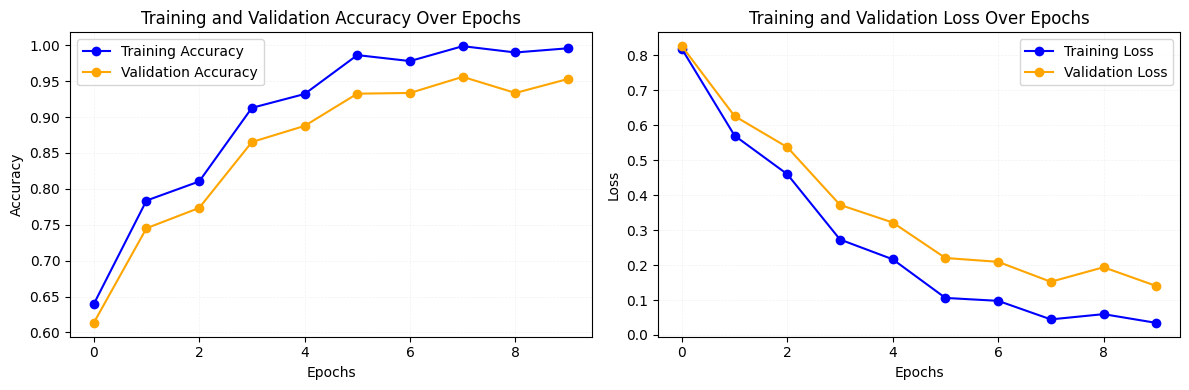

In [13]:
# Plot Testing Accuracy and Loss with a curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
# Plot accuracy curves
plt.plot(train_accuracy_list, label='Training Accuracy', marker='o',color='blue')
plt.plot(val_accuracy_list, label='Validation Accuracy', marker='o',color='orange')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.1)

plt.subplot(1, 2, 2)
# Plot accuracy curves
plt.plot(train_loss_list, label='Training Loss', marker='o',color='blue')
plt.plot(val_loss_list, label='Validation Loss', marker='o',color='orange')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.1)

plt.tight_layout()
plt.show()

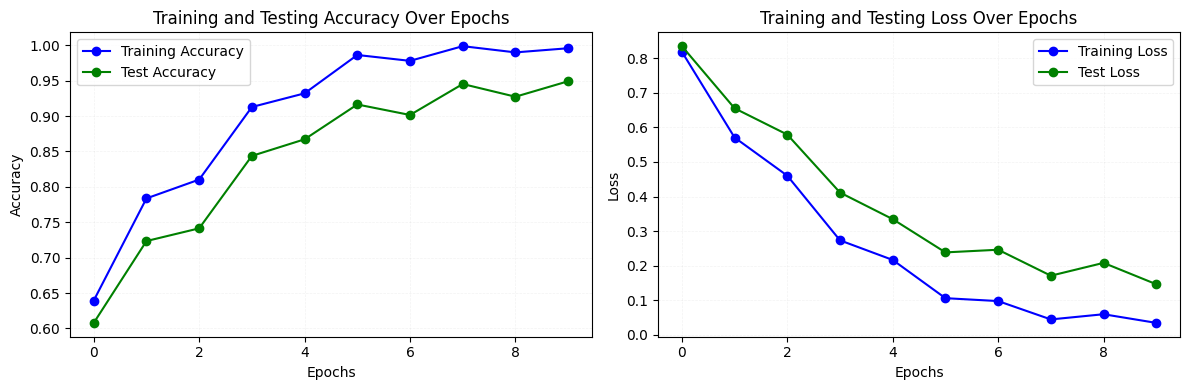

In [14]:
# Plot Testing Accuracy and Loss with a curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
# Plot accuracy curves
plt.plot(train_accuracy_list, label='Training Accuracy', marker='o',color='blue')
plt.plot(test_accuracy_list, label='Test Accuracy', marker='o',color='green')
plt.title('Training and Testing Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.1)

plt.subplot(1, 2, 2)
# Plot accuracy curves
plt.plot(train_loss_list, label='Training Loss', marker='o',color='blue')
plt.plot(test_loss_list, label='Test Loss', marker='o',color='green')
plt.title('Training and Testing Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.1)

plt.tight_layout()
plt.show()

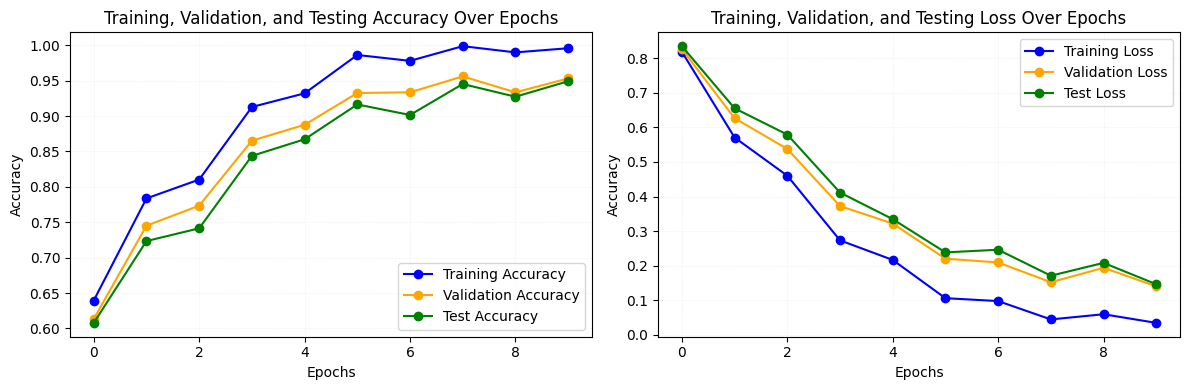

In [15]:
# Plot Testing Accuracy and Loss with a curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
# Plot accuracy curves
plt.plot(train_accuracy_list, label='Training Accuracy', marker='o',color='blue')
plt.plot(val_accuracy_list, label='Validation Accuracy', marker='o',color='orange')
plt.plot(test_accuracy_list, label='Test Accuracy', marker='o',color='green')
plt.title('Training, Validation, and Testing Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.1)

plt.subplot(1, 2, 2)
# Plot accuracy curves
plt.plot(train_loss_list, label='Training Loss', marker='o',color='blue')
plt.plot(val_loss_list, label='Validation Loss', marker='o',color='orange')
plt.plot(test_loss_list, label='Test Loss', marker='o',color='green')
plt.title('Training, Validation, and Testing Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.1)

plt.tight_layout()
plt.show()

In [17]:
# Get predictions on the test set
predictions = model.predict(np.expand_dims(test_data, axis=-1))
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)

40/40 [==============================] - 2s 45ms/step


In [18]:
# Display the classification report
class_names = ['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented']
print(classification_report(true_labels, predicted_labels, target_names=class_names))

                    precision    recall  f1-score   support

     Mild_Demented       0.98      0.94      0.96       201
 Moderate_Demented       1.00      1.00      1.00         6
      Non_Demented       0.93      0.99      0.96       643
Very_Mild_Demented       0.97      0.90      0.93       430

          accuracy                           0.95      1280
         macro avg       0.97      0.95      0.96      1280
      weighted avg       0.95      0.95      0.95      1280



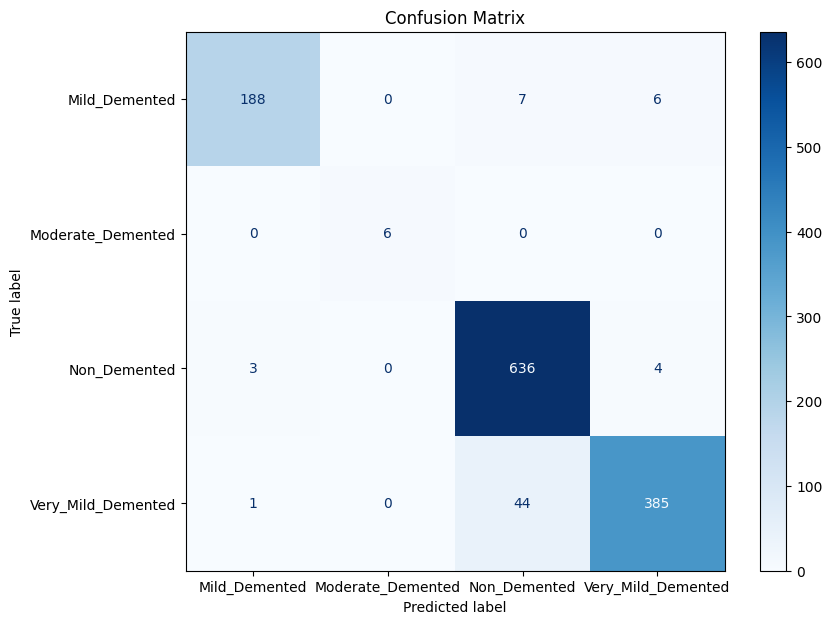

In [19]:


# Plot the confusion matrix with adjusted figure size
fig, ax = plt.subplots(figsize=(9, 7))  # Adjust the figure size

cm = confusion_matrix(true_labels, predicted_labels)
classes = ['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', values_format='d', ax=ax)  # Pass the axis to ConfusionMatrixDisplay

plt.title('Confusion Matrix')
plt.show()

In [20]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(np.expand_dims(test_data, axis=-1), test_labels)
print(f"Test Accuracy: {test_accuracy}")

40/40 [==============================] - 1s 24ms/step - loss: 0.1464 - accuracy: 0.9492
Test Accuracy: 0.94921875


In [21]:
# Extract features using the trained CNN model
train_features = model.predict(np.expand_dims(train_data, axis=-1))
val_features = model.predict(np.expand_dims(val_data, axis=-1))
test_features = model.predict(np.expand_dims(test_data, axis=-1))

40/40 [==============================] - 1s 24ms/step


In [22]:
# Build and train the SVM model on the extracted features
svm_model = SVC(kernel='linear', decision_function_shape='ovr')
svm_model.fit(train_features, np.argmax(train_labels, axis=1))

SVC(kernel='linear')

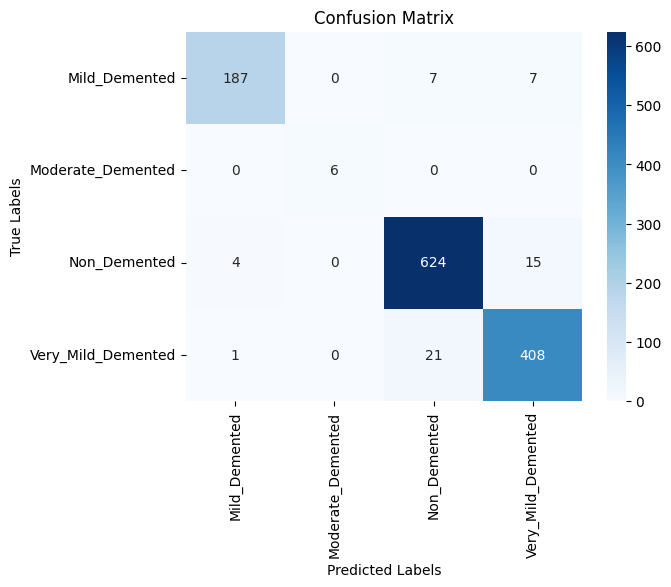

                    precision    recall  f1-score   support

     Mild_Demented       0.97      0.93      0.95       201
 Moderate_Demented       1.00      1.00      1.00         6
      Non_Demented       0.96      0.97      0.96       643
Very_Mild_Demented       0.95      0.95      0.95       430

          accuracy                           0.96      1280
         macro avg       0.97      0.96      0.97      1280
      weighted avg       0.96      0.96      0.96      1280



In [23]:
# Predictions on the test set
svm_predictions = svm_model.predict(test_features)

# Confusion matrix
cm = confusion_matrix(np.argmax(test_labels, axis=1), svm_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(np.argmax(test_labels, axis=1), svm_predictions, target_names=class_names))


In [25]:
# Predictions on the test set
svm_val_predictions = svm_model.predict(val_features)

In [26]:
# Evaluate the SVM model on the validation set
val_accuracy = accuracy_score(np.argmax(val_labels, axis=1), svm_val_predictions)
print(f"Validation Accuracy: {val_accuracy}")

Validation Accuracy: 0.96484375


In [27]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(np.expand_dims(test_data, axis=-1), test_labels)
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Loss: {test_loss}")

40/40 [==============================] - 1s 24ms/step - loss: 0.1464 - accuracy: 0.9492
Test Accuracy: 0.94921875
Test Loss: 0.14638042449951172


1/1 [==============================] - 0s 127ms/step


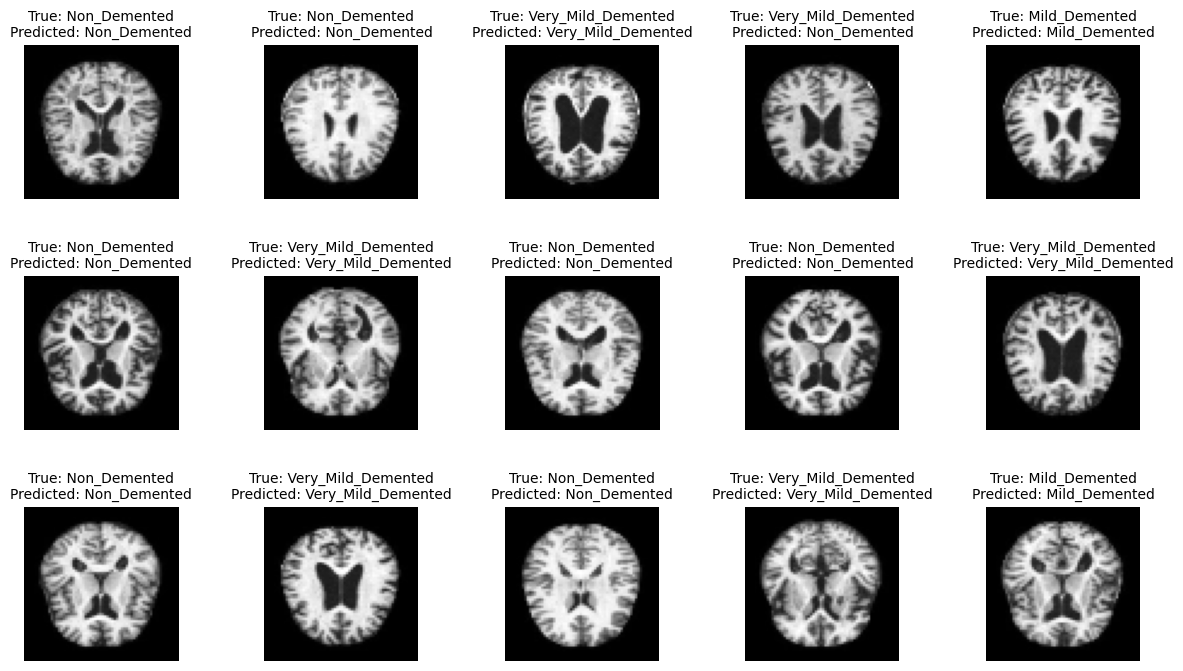

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def display_images_with_labels(images, true_labels, predicted_labels, class_names, num_images=15):
    """
    Display a grid of images with true and predicted labels.

    Parameters:
    - images: List of image data.
    - true_labels: List of true labels.
    - predicted_labels: List of predicted labels.
    - class_names: List of class names.
    - num_images: Number of images to display.

    Returns:
    None
    """

    plt.figure(figsize=(15, 8))
    for i in range(num_images):
        plt.subplot(3, 5, i + 1)  # Display in 3 rows and 5 columns
        plt.imshow(images[i], cmap='gray')
        plt.title(f'True: {class_names[true_labels[i]]}\nPredicted: {class_names[predicted_labels[i]]}',fontdict = {'fontsize' : 10})
        plt.subplots_adjust(wspace=0.2, hspace=0.5)
        plt.axis('off')
    plt.show()

# Example usage:
# Replace these variables with your actual data
example_images = test_data[:15]  # Replace with your actual test data
example_true_labels = np.argmax(test_labels[:15], axis=1)  # Replace with your actual true labels
example_predictions = model.predict(np.expand_dims(example_images, axis=-1))
example_predicted_labels = np.argmax(example_predictions, axis=1)  # Replace with your actual predicted labels

# Use the function to display 15 images with true and predicted labels
display_images_with_labels(example_images, example_true_labels, example_predicted_labels, class_names)


In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming 'train_features' and 'train_labels' are your CNN-extracted features and labels
# Flatten the feature vectors if needed
train_features_flattened = train_features.reshape(train_features.shape[0], -1)

# Normalize the features
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features_flattened)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(train_features_scaled, train_labels, test_size=0.2, random_state=42)

# Initialize the k-NN model
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can adjust the value of 'n_neighbors'

# Fit the k-NN model
knn_model.fit(X_train, y_train)

# Predict on the test set
knn_predictions = knn_model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, knn_predictions)
print(f"Accuracy: {accuracy}")


Accuracy: 1.0


In [43]:
# Install PyTorch Geometric
!pip install torch-scatter -f https://pytorch-geometric.com/whl/torch-1.10.0+cpu.html
!pip install torch-sparse -f https://pytorch-geometric.com/whl/torch-1.10.0+cpu.html
!pip install torch-cluster -f https://pytorch-geometric.com/whl/torch-1.10.0+cpu.html
!pip install torch-geometric

Looking in links: https://pytorch-geometric.com/whl/torch-1.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp310-cp310-linux_x86_64.whl size=495089 sha256=1a48ca514ff005aca215dd0efb62c9016ed8c82200420a5897daef4fa36dcd87
  Stored in directory: /root/.cache/pip/wheels/92/f1/2b/3b46d54b134259f58c8363568569053248040859b1a145b3ce
Successfully built torch-scatter
Looking in links: https://pytorch-geometric.com/whl/torch-1.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/cli/base_command.py", line 169, in exc_logging_wrapper
    status = run_func(*args)
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/cli/req_command.py", line 242, in wrapper
    

In [42]:


import torch_geometric.nn as gnn
from torch_geometric.data import Data

# Assuming 'X_train' and 'X_test' are your node features, 'edge_index' are your graph edges  train_features  train_labels
# 'y_train' and 'y_test' are your node labels
import torch

# Assuming you have four nodes and three edges
# Nodes: 0, 1, 2, 3
# Edges: (0, 1), (1, 2), (2, 3)

edge_index = torch.tensor([[0, 1, 2],
                           [1, 2, 3]])

# This tensor represents the edges: (0, 1), (1, 2), (2, 3)


# Create PyTorch Geometric Data objects
train_data = Data(x=torch.FloatTensor(train_features), edge_index=edge_index, y=torch.LongTensor(train_labels))
test_data = Data(x=torch.FloatTensor(test_features), edge_index=edge_index, y=torch.LongTensor(test_labels))

# Define Pearson Recursive Graph Convolutional Neural Network (R-GCN) model
class RGCNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RGCNModel, self).__init__()
        self.conv1 = gnn.RGCNConv(input_size, hidden_size)
        self.conv2 = gnn.RGCNConv(hidden_size, output_size)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

# Instantiate the R-GCN model
rgcn_model = RGCNModel(input_size=X_train.shape[1], hidden_size=64, output_size=num_classes)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rgcn_model.parameters(), lr=0.001)

# Training
num_epochs = 10
for epoch in range(num_epochs):
    rgcn_model.train()
    optimizer.zero_grad()
    output = rgcn_model(train_data)

    # Use negative log likelihood loss (NLLLoss) with log_softmax on the model output
    log_probs = F.log_softmax(output, dim=1)
    loss = criterion(log_probs, train_data.y)
    loss.backward()
    optimizer.step()

# Evaluation
rgcn_model.eval()
with torch.no_grad():
    test_output = rgcn_model(test_data)
    _, predicted = torch.max(test_output, 1)

# Evaluate accuracy
accuracy = accuracy_score(y_test, predicted.numpy())
print(f"R-GCN Accuracy: {accuracy}")


/usr/local/lib/python3.10/dist-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


RuntimeError: ignored

In [31]:
!pip install dgl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 13.6 MB/s eta 0:00:00
